### Импорт

In [1]:
import json
import matplotlib.pyplot as plt

### Импорт датасета

In [2]:
data = [] # Массив всех сессий
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            data.append(json.loads(line))

### Функция создания графа, где вершины — товары, а ребра — переходы между соседними товарами в сессии

In [3]:
def create_graph(data):
    graph = {}

    for session in data:
        for i in range(len(session)- 1):
            u = session[i]
            v = session[i + 1]

            if u not in graph:
                graph[u] = {}

            if v not in graph[u]:
                graph[u][v] = 0

            graph[u][v] += 1

    return graph 

### Функция подсчета веротности P(j | i) - перехода от одного товара к другому

In [4]:
def conversion_probability(graph):
    probs = {}

    for u in graph:
        probs[u] = {}

        total = sum(graph[u].values())

        for v in graph[u]:
            count = graph[u][v]
            probability = count / total

            probs[u][v] = probability

    return probs

### Функция, которая считает насколько хорош каждый переход для рекомендации

In [5]:
def get_conversion_trust_level(graph, probs, train_items, lambda_value = 5):
    total_train_views = sum(train_items.values())

    conversion_trust_level = []

    for u in graph:
        total_out = sum(graph[u].values())
        for v in graph[u]:
            probability = probs[u][v]
            count = graph[u][v]
            popularity = train_items[v] / total_train_views

            score = (count + lambda_value * popularity) / (total_out + lambda_value) # Реализация формулы

            conversion_trust_level.append((u, v, score, probability, count, popularity))

    conversion_trust_level.sort(key=lambda x: x[2], reverse=True)

    return conversion_trust_level

### Для выбора рекомендуемых товаров используется формула, где учитывается:   
count(i -> j) - количество переходов из i в j,  
total_out(i) — сколько всего переходов из i,  
popularity(j) — глобальная вероятность товара j,    
lambda - степень сглаживания  

### Функция, которая строит рекомендации для одной конкретной сессии

In [6]:
def recommend_next(session, score_graph, popular_items, graph, k=10):
    previous_item = session[-1]

    recommendations = []
    total_out = 0

    if previous_item in graph:
        total_out = sum(graph[previous_item].values())

    if total_out >= 30:
        conversion_slots = 9
    else:
        conversion_slots = 5


    if previous_item in score_graph:   
        for v, score, probability, count, popularity in score_graph[previous_item]:
            if v not in recommendations and v != previous_item:
                recommendations.append(v)

            if len(recommendations) == conversion_slots:
                break

    if len(recommendations) == k:
         return recommendations
    
    
    for item in popular_items:
        if item not in recommendations and item != previous_item:
            recommendations.append(item)

        if len(recommendations) == k:
            break

    return recommendations

При построении рекомендаций мы разбавляем рекомендации, основанные на переходах популярными товарами. Если переходы случались часто (>=30) - то они дают достаточно надежную информацию и к ним добавляется только 1 товар из популярных, заменяя наименее надежный переход. Если нет, то из популярных берется половина рекомендуемых товаров, т.к редкие переходы весьма ненадежны.

### Переменные для статистики

In [7]:
items = {}           # Список всех товаров, с количеством их появлений
                     # Товар : сколько раз встретился

min_lenght = 1000    # Минимальная длина сессии
max_lenght = 0       # Максимальная длина сессии

sessions_with_repeats = 0  # Количество сессий, где есть хотя бы один повторяющийся товар

train_data = []      # Массив для обучения
test_data = []       # Массив для тестирования

### Обход всех сессий 

In [8]:
for session in data:
    sesion_lenght = len(session)

    # Ищем максимальную длину сессии
    if sesion_lenght > max_lenght:
        max_lenght = sesion_lenght  
    
    # Проверяем корректность данных (что мин. длина = 3)
    if sesion_lenght < min_lenght: 
        min_lenght = sesion_lenght  

    # Разбиваем данные на тестовые и обучающие
    train_session = session[:-1]
    test_session = session[-1]
    
    train_data.append(train_session)
    test_data.append(test_session)

    # Создаем множество встретившихся товаров в текущей сессии
    seen_items = set()
    has_repeat = False


    # Обход всех товаров в текущей сессии
    for item in session:
            
        # Обновляем список всех товаров
        if item not in items: 
            items[item] = 0
        items[item] += 1

        # Проверяем повторился ли товар в сессии 
        if item in seen_items:
            has_repeat = True

        seen_items.add(item)

    if has_repeat:
        sessions_with_repeats += 1


unique_items = len(items)                                                   # Ищем количество уникальных товаров
total_views = sum(items.values())                                           # Ищем общее количество просмотров
average_lenght = total_views / len(data)                                    # Ищем среднюю длину сессии
percent_sessions_with_repeats = sessions_with_repeats / len(data) * 100     # Ищем % сессий, где товар повторялся

### Вывод статистики

In [9]:
print(f"#1. Количество сессий: {len(data)}")
print(f"#2. Количество уникальных товаров: {unique_items}")
print(f"#3. Общее количество просмотров: {total_views}")
print(f"#4. Средняя длина сессии: {average_lenght:.2f}")
print(f"#5. Минимальная длина сессии: {min_lenght}")
print(f"#6. Максимальная длина сессии: {max_lenght}")
print(f"#7. Сессий, где хотя бы один товар повторялся: {percent_sessions_with_repeats:.2f}%")

#1. Количество сессий: 2565
#2. Количество уникальных товаров: 400
#3. Общее количество просмотров: 26843
#4. Средняя длина сессии: 10.47
#5. Минимальная длина сессии: 3
#6. Максимальная длина сессии: 20
#7. Сессий, где хотя бы один товар повторялся: 60.51%


### Подсчет частот появления товаров

In [10]:
frequencies = {}            # Словарь частоты появления товаров, с их количеством 
                            # Частота : сколько разных товаров имеют такую частоту | номера таких товаров

for item in items:
    freq = items[item]

    if freq not in frequencies:
        frequencies[freq] = {
            "count": 0,
            "items": []
        } 

    frequencies[freq]["count"] += 1
    frequencies[freq]["items"].append(item)

### Создание графика распределения частот появления товаров

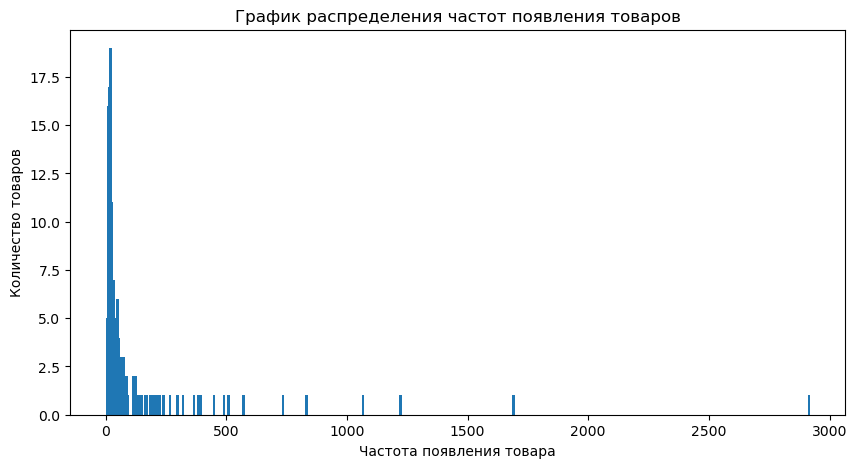

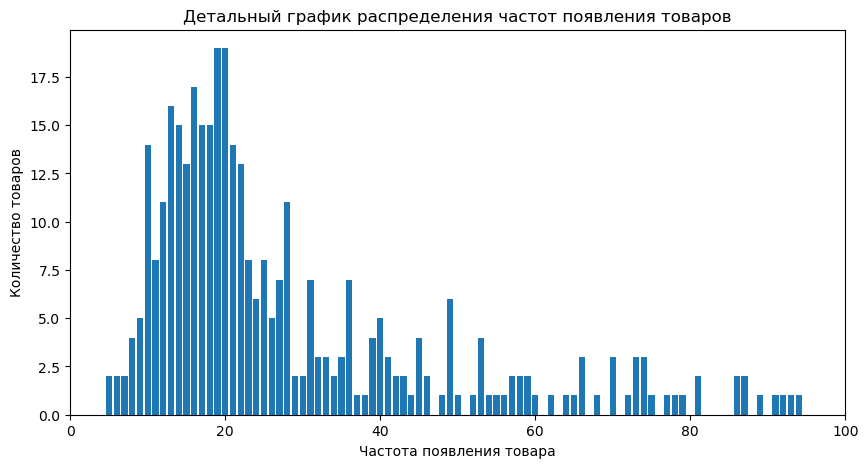

In [11]:
x = sorted(frequencies.keys())
y = []

for freq in x:
    y.append(frequencies[freq]["count"])

plt.figure(figsize=(10, 5))
plt.bar(x, y, width=10)

plt.xlabel("Частота появления товара")
plt.ylabel("Количество товаров")
plt.title("График распределения частот появления товаров")


x = sorted(frequencies.keys())
y = []

for freq in x:
    y.append(frequencies[freq]["count"])

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.xlim(0, 100)

plt.xlabel("Частота появления товара")
plt.ylabel("Количество товаров")
plt.title("Детальный график распределения частот появления товаров")

plt.show()

Распределение частот появления товаров сильно неравномерное. Большинство товаров встречаются относительно редко, примерно в диапазоне 10–30 появлений, но есть небольшое количество товаров, которые встречаются намного чаще остальных. Следовательно, при построении рекомендательной модели частота появления товаров (популярность), должна учитываться, но только как дополнительная метрика, чтобы избежать преобладания часто встречающихся товаров в рекомендациях.

### Создаем граф на основе данных для обучения

In [12]:
graph = create_graph(train_data)  

### Подсчитываем вероятности P(j | i) - перехода от одного товара к другому

In [13]:
probs = conversion_probability(graph)

### Подсчитываем статистику для переходов

In [14]:
conversions = []        # Массив всех переходов

for u in graph:
    for v in graph[u]:
        probability = probs[u][v]
        count = graph[u][v]

        conversions.append((u, v, count, probability))
        
conversion_frequencies = {}      # Словарь частоты появления переходов, с их количеством 
                                 # Частота : сколько разных переходов имеют такую частоту

one_time_conversions = []        # Массив переходов, случившихся только один раз
same_item_conversions = []       # Массив переходов, случившихся из товара в тот же самый товар

for u, v, count, probability in conversions:
    if count not in conversion_frequencies:
        conversion_frequencies[count] = 0

    conversion_frequencies[count] += 1

    # Находим количество товаров, где количество переходов = 1

    if count == 1:                                                      
        one_time_conversions.append((u, v, count, probability))

    # Подсчитываем количество переходов вида товар -> тот же товар

    if u == v:
        same_item_conversions.append((u, v, count, probability))

print(f"#8. Количество переходов, которые встретились ровно 1 раз: {len(one_time_conversions)}")
print(f"#9. Количество переходов вида товар -> тот же товар: {len(same_item_conversions)}")

#8. Количество переходов, которые встретились ровно 1 раз: 5903
#9. Количество переходов вида товар -> тот же товар: 0


Поскольку в выборке не существует переходов вида товар -> тот же товар, можно убрать его из рекомендаций

### Создание графика распределения частот появления переходов

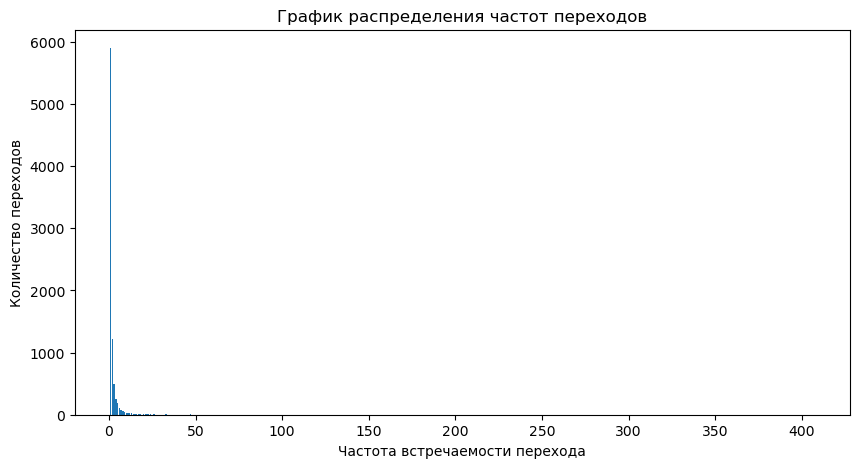

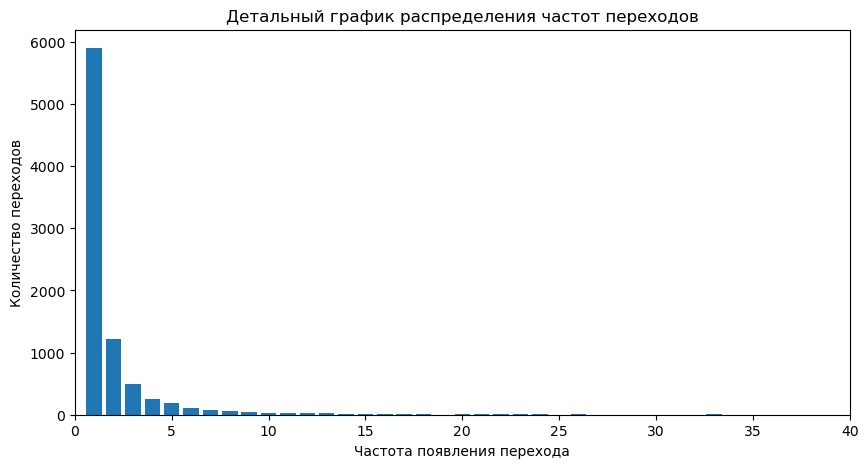

In [15]:
x = sorted(conversion_frequencies.keys())
y = []

for count in x:
    y.append(conversion_frequencies[count])


plt.figure(figsize=(10, 5))
plt.bar(x, y)

plt.xlabel("Частота встречаемости перехода")
plt.ylabel("Количество переходов")
plt.title("График распределения частот переходов")

plt.show()


x = sorted(conversion_frequencies.keys())
y = []

for count in x:
    y.append(conversion_frequencies[count])


plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.xlim(0, 40)

plt.xlabel("Частота появления перехода")
plt.ylabel("Количество переходов")
plt.title("Детальный график распределения частот переходов")

plt.show()

Распределение частот переходов крайне разреженное. Подавляющее большинство переходов встречается очень малое количество раз, особенно ровно 1 раз - встречается 5903 переход. Значит, многие переходы между товарами не слишком надежны и могут быть случайными. Соответственно, при построении рекомендательной модели нельзя опираться только на условную вероятность перехода P(j | i). Для уменьшения влияния случайных переходов на итоговые предложения в формуле, описанной выше используется параметр alpha отвечающий за редкость перехода, зависящий от count(i -> j).

### Подсчитываем количество товаров без исходящих переходов

In [16]:
train_items = {}      # Массив всех элементов из обучающей выборки    

for session in train_data:
    for item in session:
        if item not in train_items:
            train_items[item] = 0
        
        train_items[item] += 1

items_without_outgoing = {}   # Товары без исходящих переходов

for item in train_items:
    if item not in graph:
        items_without_outgoing[item] = train_items[item]

print(f"#10. Количество товаров без исходящих переходов: {len(items_without_outgoing)}")

#10. Количество товаров без исходящих переходов: 0


Поскольку в выборке не оказалось товаров без исходящих переходов, при нахождение рекомендованных товаров не нужно обрабатывать случай, когда рекомендательной системе не на чем строить свое предположение.

### Создаем массив, отсортированный по тому насколько хорош каждый переход для рекомендации

In [17]:
sorted_conversions = get_conversion_trust_level(graph, probs, train_items)

### Создаем граф переходов, где так же хранится уровень рекомендации

In [18]:
score_graph = {}

for u, v, score, probability, count, popularity in sorted_conversions:
    if u not in score_graph:
        score_graph[u] = []

    score_graph[u].append((v, score, probability, count, popularity))

### Создаем список популярных товаров, чтобы предложить их, если будет меньше 10 рекомендаций

In [19]:
popular_items = []

sorted_train_items = sorted(train_items.items(), key=lambda x: x[1], reverse=True)

for item, count in sorted_train_items:
    popular_items.append(item)

Если рекомендательная модель не знает что предложить основываясь на графе, то она предлагает самые популярные товары

### Оцениваем рекомендательную модель на тесте по метрике Hit@10

In [20]:
# ТЕСТ рекомендательной модели
hits = 0
k = 10

for i in range(len(train_data)):
    test_session = train_data[i]
    true_item = test_data[i]

    recommendations = recommend_next(test_session, score_graph, popular_items, graph, k)   # Используем функцию рекомендующую товары

    if true_item in recommendations:
        hits += 1

hit_at_10 = hits * 100 / len(test_data)

print(f"Количество тестовых сессий: {len(test_data)}\n")
print(f"Количество попаданий: {hits}")
print(f"Hit@10 = {hit_at_10:.2f}%\n")

# ТЕСТ бейзлайн моджели, предлагающей 10 самых популярных товаров

hits = 0
k = 10

baseline_recommendations = popular_items[:k]

for true_item in test_data:
    if true_item in baseline_recommendations:
        hits += 1

baseline_hit_at_10 = hits * 100 / len(test_data)

print(f"Количество попаданий baseline: {hits}")
print(f"Baseline Hit@10 = {baseline_hit_at_10:.2f}%")

Количество тестовых сессий: 2565

Количество попаданий: 1371
Hit@10 = 53.45%

Количество попаданий baseline: 985
Baseline Hit@10 = 38.40%


Полученная модель показала результат Hit@10 = 53.45%, что на 39.2% лучше по сравнению с baseline моделью рекомендующей популярные товары. Таким образом мы можем наглядно наблюдать, что использование статистики по переходам между товарами улучшает качество рекомендаций.
